In [2]:
# Install all the libraries we need for the entire project
# Run this once; you can skip it after the first time
!pip install transformers datasets torch torchvision
!pip install matplotlib scikit-learn gradio wandb seaborn

In [3]:
# datasets: HuggingFace library to download and manage datasets
# matplotlib: for visualizing sample images
# os: to check folders and file paths on disk
from datasets import load_dataset
import matplotlib.pyplot as plt
import os

In [5]:
# The original 'nielsr/eurosat-rgb' path no longer exists on HuggingFace
# Use 'blanchon/EuroSAT_RGB' instead — same dataset, active and maintained
dataset = load_dataset("blanchon/EuroSAT_RGB")

print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})


In [6]:
# Extract the 10 land-use category names from the dataset
class_names = dataset["train"].features["label"].names

print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

Number of classes: 10
Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']


In [7]:
# Count how many images exist per class in the training set
# A balanced dataset means the model won't be biased toward any one class
from collections import Counter

train_labels = dataset["train"]["label"]
label_counts = Counter(train_labels)

print("Images per class (training set):")
for label_id, count in sorted(label_counts.items()):
    print(f"  {class_names[label_id]:<25} → {count} images")

Images per class (training set):
  Annual Crop               → 1791 images
  Forest                    → 1787 images
  Herbaceous Vegetation     → 1799 images
  Highway                   → 1505 images
  Industrial Buildings      → 1492 images
  Pasture                   → 1195 images
  Permanent Crop            → 1481 images
  Residential Buildings     → 1863 images
  River                     → 1460 images
  SeaLake                   → 1827 images


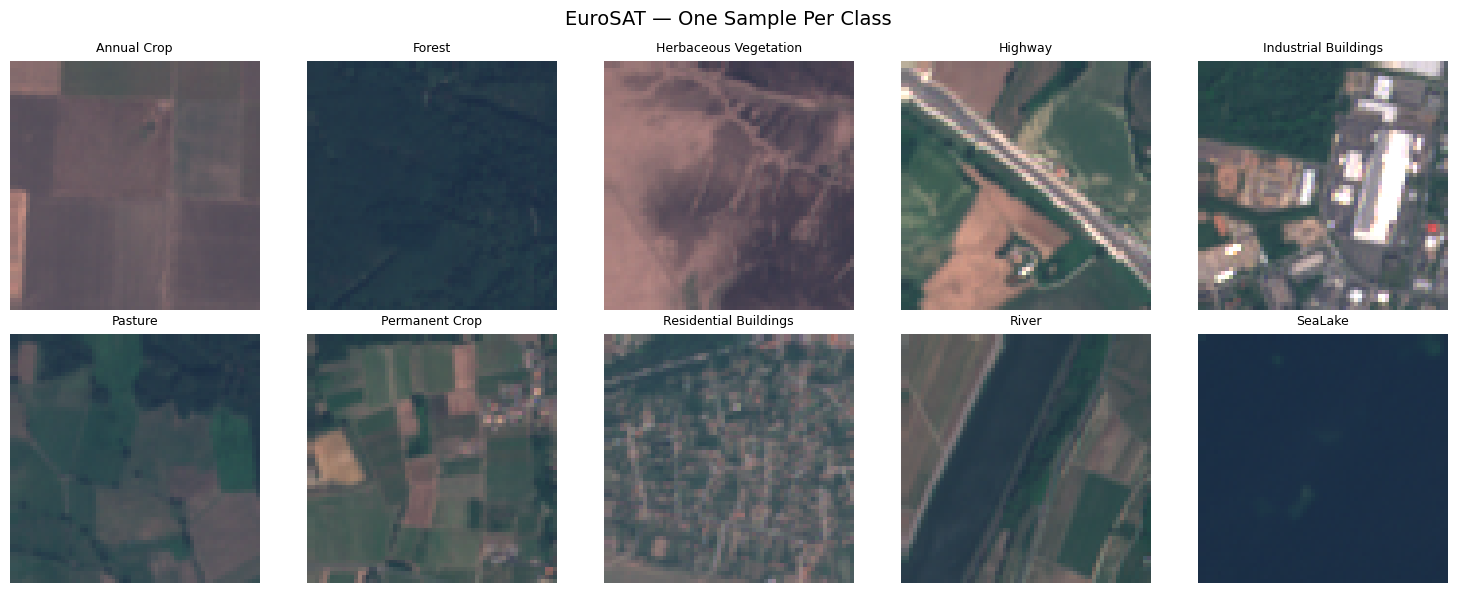

Sample grid saved to /teamspace/studios/this_studio/satellite-land-classifier/results/class_samples.png


In [12]:
# Display one sample image from each of the 10 classes
# We manually find the first occurrence of each label instead of using filter()
# This is faster and more compatible across dataset versions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("EuroSAT — One Sample Per Class", fontsize=14)

# Build a dict of {label_id: sample} by scanning the dataset once
samples = {}
for sample in dataset["train"]:
    label = sample["label"]
    if label not in samples:
        samples[label] = sample
    if len(samples) == len(class_names):
        break  # Stop once we have one sample per class

for label_id, ax in enumerate(axes.flatten()):
    ax.imshow(samples[label_id]["image"])
    ax.set_title(class_names[label_id], fontsize=9)
    ax.axis("off")

plt.tight_layout()

# Save to the project root's results folder, not the notebooks folder
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
results_dir = os.path.join(project_root, "results")
os.makedirs(results_dir, exist_ok=True)

plt.savefig(os.path.join(results_dir, "class_samples.png"), dpi=150)
plt.show()
print(f"Sample grid saved to {results_dir}/class_samples.png")

In [20]:
# Save the dataset locally so future notebooks load instantly
# Without this, every notebook would re-download from the internet
save_path = "../data/eurosat"
os.makedirs(save_path, exist_ok=True)
dataset.save_to_disk(save_path)

print(f"Dataset saved to {save_path}")

Saving the dataset (0/1 shards):   0%|          | 0/16200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5400 [00:00<?, ? examples/s]

Dataset saved to ../data/eurosat


In [22]:
# Re-load from disk and confirm everything saved correctly
# This is the exact line you'll use at the top of every future notebook
from datasets import load_from_disk

dataset_reloaded = load_from_disk("../data/eurosat")
print("Reloaded successfully!")
print(dataset_reloaded)

# Sanity check: make sure image count matches what we downloaded
assert len(dataset_reloaded["train"]) == len(dataset["train"]), "Mismatch!"
print("✅ All checks passed. Dataset is ready.")

Reloaded successfully!
DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})
✅ All checks passed. Dataset is ready.


In [23]:
# Print a final summary of what we have
print("=" * 40)
print("DATASET DOWNLOAD COMPLETE")
print("=" * 40)
print(f"  Total training images:   {len(dataset['train'])}")
print(f"  Total validation images: {len(dataset['validation'])}")
print(f"  Total test images:       {len(dataset['test'])}")
print(f"  Number of classes:       {len(class_names)}")
print(f"  Saved to:                ../data/eurosat")
print(f"  Sample grid saved to:    ./results/class_samples.png")
print("=" * 40)
print("Next step: open 01_exploration.ipynb")

DATASET DOWNLOAD COMPLETE
  Total training images:   16200
  Total validation images: 5400
  Total test images:       5400
  Number of classes:       10
  Saved to:                ../data/eurosat
  Sample grid saved to:    ./results/class_samples.png
Next step: open 01_exploration.ipynb
